In [563]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

In [857]:
import pypsatopo

In [564]:
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

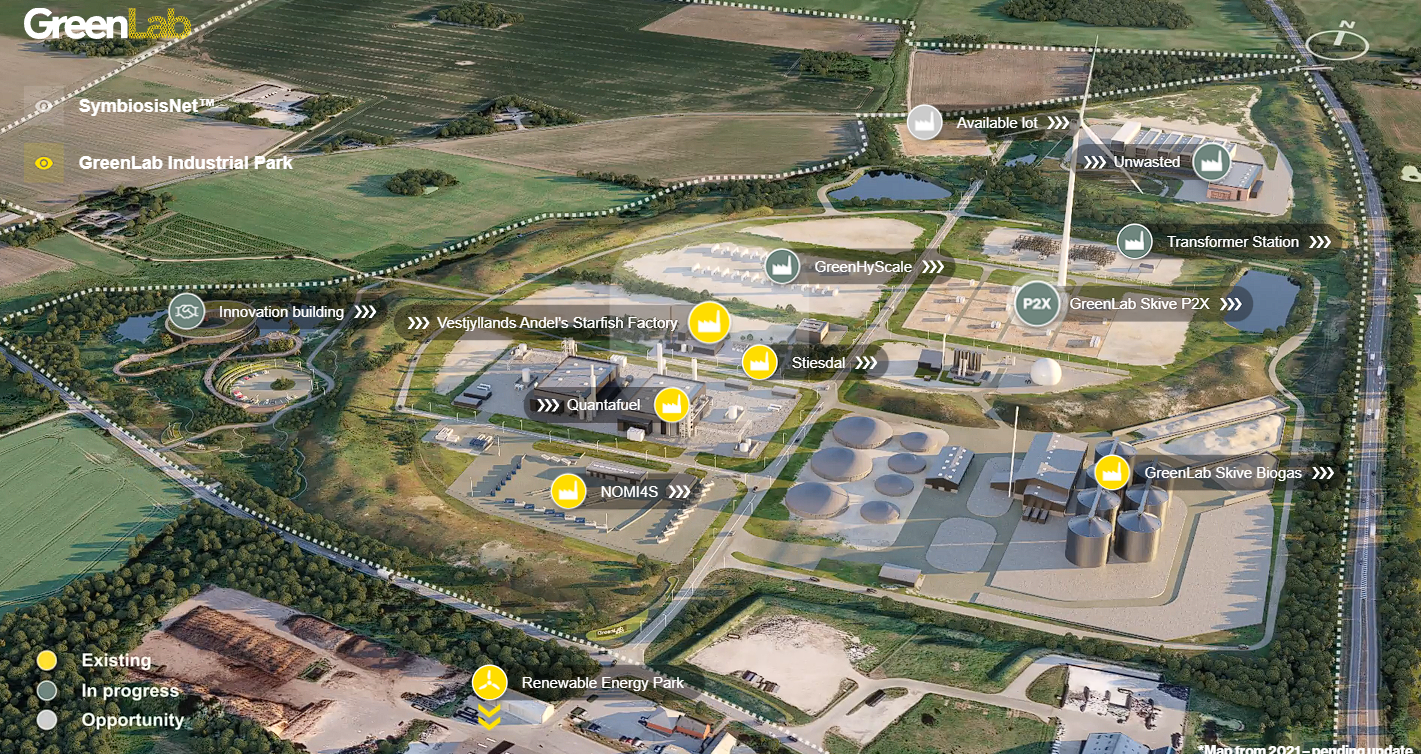

- 22 MW / 88 MWh, battery
- 10 MW, electric boiler
- 25 - 30 MW, biogas plant
- 6 MW electrolyser
- 1.5 MWh Electrical Load per hour
- Heat consumption biogas plant 5 MWh
- 54 MW onshore wind
- 36 MW solar photvoltaic

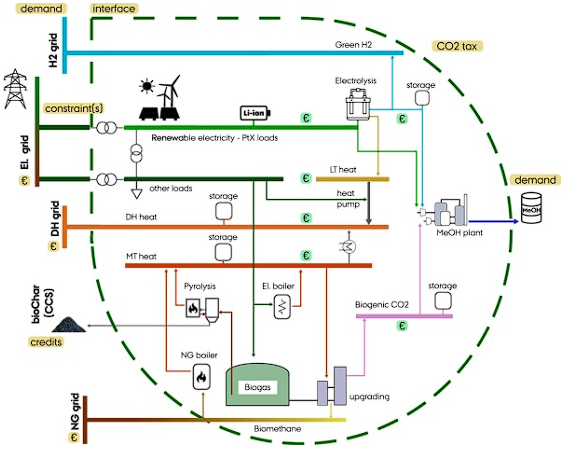

In [565]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [566]:

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [567]:
from IPython.display import display, HTML

display(HTML(costs.to_html(max_rows=1000)))  # adjust

parameter,Bottom storage temperature,C in fuel,C stored,CO2 intensity,CO2 stored,FOM,Motor size,Top storage temperature,VOM,ammonia-input,c_b,c_v,capacity,capture rate,capture_rate,carbondioxide-input,carbondioxide-output,clinker-input,coal-input,commodity,compression-electricity-input,compression-heat-output,discount rate,district heat surcharge,district heat-input,economic_lifetime,efficiency,efficiency-biochar,efficiency-biomass,efficiency-electricity,efficiency-heat,efficiency-hydrogen,efficiency-tot,electricity-input,energy to power ratio,fuel,gas-input,hbi-input,heat-input,heat-output,hydrogen-input,investment,lifetime,lohc-input,methane-input,methanol-input,min_fill_level,naphtha-input,nitrogen-input,oil-input,ore-input,p_nom_ratio,pelletizing cost,scrap-input,slag-input,standing losses,temperature difference,wood-input,yield-biochar
technology,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Alkaline electrolyzer large size,NaN,NaN,NaN,0.0000,NaN,2.8000,NaN,NaN,0.2389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,1.3800,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,4.290306e+05,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alkaline electrolyzer medium size,NaN,NaN,NaN,0.0000,NaN,2.3000,NaN,NaN,0.2389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,1.4160,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,5.060332e+05,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alkaline electrolyzer small size,NaN,NaN,NaN,0.0000,NaN,2.3000,NaN,NaN,0.1934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,1.4100,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,5.829220e+05,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ammonia cracker,NaN,NaN,NaN,0.0000,NaN,4.3000,NaN,NaN,0.0000,1.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,1.123945e+06,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEV Bus city,NaN,NaN,NaN,0.0000,NaN,0.0003,346.5517,NaN,0.0952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,0.8585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,2.224856e+05,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEV Coach,NaN,NaN,NaN,0.0000,NaN,0.0002,358.6207,NaN,0.0952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,0.8446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,3.030254e+05,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEV Truck Semi-Trailer max 50 tons,NaN,NaN,NaN,0.0000,NaN,0.0004,555.1724,NaN,0.0952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,1.3936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,1.512139e+05,10.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEV Truck Solo max 26 tons,NaN,NaN,NaN,0.0000,NaN,0.0002,382.7586,NaN,0.0952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,0.8755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,2.824187e+05,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEV Truck Trailer max 56 tons,NaN,NaN,NaN,0.0000,NaN,0.0003,710.3448,NaN,0.0952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,1.5446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,1.677228e+05,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [568]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [569]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [671]:
#solar_pv_2019 = pd.read_csv("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive/2019_Skive_SolarPV.csv")
#wind_speed_2019 = pd.read_csv("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive/2019_Skive_WindSpeeds.csv")

solar_pv_data = pd.read_csv("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive/pv_optimal.csv", sep = ";")
onshore_wind_data = pd.read_csv("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive/onshore_wind_1979-2017.csv", sep = ";")
DK1_data_2017 = pd.read_excel("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive/2017_DK1_SpotSprice_Load.xlsx")
#DK1_data_2017 = pd.read_csv("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive/DK1_2017.csv", sep = ";")

In [672]:
DK1_data_2017.head()

,HourUTC,HourDK,GrossConsumptionMWhDK1,DK1_EUR/MWh
0,2016-12-31 23:00:00,2017-01-01 00:00:00,2020.510010,20.959999
1,2017-01-01 00:00:00,2017-01-01 01:00:00,1952.129028,20.900000
2,2017-01-01 01:00:00,2017-01-01 02:00:00,1844.377319,18.129999
3,2017-01-01 02:00:00,2017-01-01 03:00:00,1794.987427,16.030001
4,2017-01-01 03:00:00,2017-01-01 04:00:00,1722.232056,16.430000


In [673]:
solar_pv_data.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
0,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [674]:
onshore_wind_data.head()

,utc_time,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,...,LUX,LVA,NLD,NOR,POL,PRT,ROU,SVK,SVN,SWE
0,1979-01-01T00:00:00Z,0.481,0.513,0.756,0.932,0.305,0.298,0.712,0.639,0.076,...,0.585,0.527,0.316,0.468,0.385,0.524,0.462,0.390,0.110,0.365
1,1979-01-01T01:00:00Z,0.551,0.380,0.750,0.950,0.346,0.300,0.704,0.628,0.077,...,0.619,0.584,0.206,0.431,0.374,0.514,0.427,0.483,0.099,0.369
2,1979-01-01T02:00:00Z,0.602,0.246,0.733,0.963,0.397,0.304,0.673,0.630,0.073,...,0.619,0.568,0.170,0.395,0.358,0.510,0.488,0.599,0.093,0.371
3,1979-01-01T03:00:00Z,0.484,0.170,0.688,0.949,0.415,0.297,0.635,0.630,0.062,...,0.612,0.508,0.156,0.384,0.336,0.474,0.553,0.614,0.120,0.360
4,1979-01-01T04:00:00Z,0.387,0.125,0.647,0.909,0.426,0.299,0.604,0.626,0.056,...,0.598,0.468,0.139,0.383,0.321,0.434,0.594,0.589,0.134,0.353


In [767]:
solar_pv_data['utc_time'] = pd.to_datetime(solar_pv_data['utc_time']).dt.tz_localize(None)
solar_pv_data.index = pd.DatetimeIndex(solar_pv_data['utc_time'])

onshore_wind_data['utc_time'] = pd.to_datetime(onshore_wind_data['utc_time']).dt.tz_localize(None)
onshore_wind_data.index = pd.DatetimeIndex(onshore_wind_data['utc_time'])

DK1_data_2017["HourUTC"] = pd.to_datetime(DK1_data_2017["HourUTC"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)
DK1_data_2017.index = pd.DatetimeIndex(DK1_data_2017["HourUTC"])


In [575]:
onshore_wind_data.head()

,utc_time,AUT,BEL,BGR,CHE,CZE,DEU,DNK,ESP,EST,...,LUX,LVA,NLD,NOR,POL,PRT,ROU,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00,1979-01-01 00:00:00,0.481,0.513,0.756,0.932,0.305,0.298,0.712,0.639,0.076,...,0.585,0.527,0.316,0.468,0.385,0.524,0.462,0.390,0.110,0.365
1979-01-01 01:00:00,1979-01-01 01:00:00,0.551,0.380,0.750,0.950,0.346,0.300,0.704,0.628,0.077,...,0.619,0.584,0.206,0.431,0.374,0.514,0.427,0.483,0.099,0.369
1979-01-01 02:00:00,1979-01-01 02:00:00,0.602,0.246,0.733,0.963,0.397,0.304,0.673,0.630,0.073,...,0.619,0.568,0.170,0.395,0.358,0.510,0.488,0.599,0.093,0.371
1979-01-01 03:00:00,1979-01-01 03:00:00,0.484,0.170,0.688,0.949,0.415,0.297,0.635,0.630,0.062,...,0.612,0.508,0.156,0.384,0.336,0.474,0.553,0.614,0.120,0.360
1979-01-01 04:00:00,1979-01-01 04:00:00,0.387,0.125,0.647,0.909,0.426,0.299,0.604,0.626,0.056,...,0.598,0.468,0.139,0.383,0.321,0.434,0.594,0.589,0.134,0.353


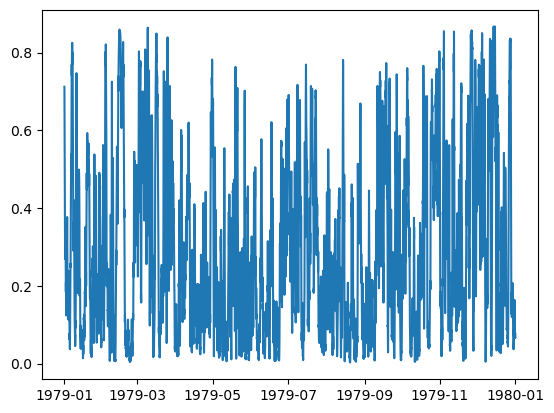

In [676]:
plt.plot(onshore_wind_data['DNK'][0:8760])

0

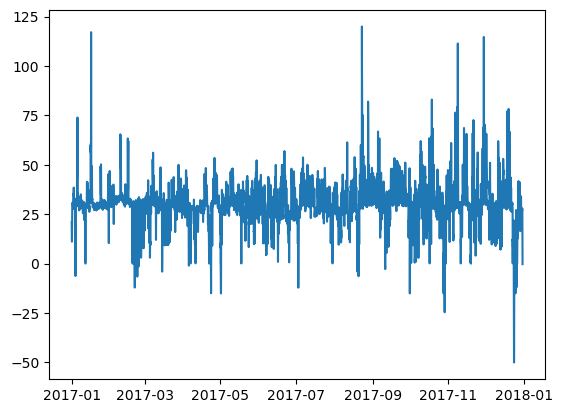

In [717]:
plt.plot(DK1_data_2017["DK1_EUR/MWh"])
DK1_data_2017["DK1_EUR/MWh"].isna().sum()


In [578]:
DK1_prod_data_2017 = pd.read_excel("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive/2017_DK1_PowerProduction.xlsx")
DK1_prod_data_2017.head()

,HourUTC,HourDK,CentralPowerMWhDK1,CommercialPowerMWhDK1,HydroPowerMWhDK1,LocalPowerMWhDK1,LocalPowerSelfConMWhDK1,OffshoreWindGe100MW_MWhDK1,OffshoreWindLt100MW_MWhDK1,OnshoreWindGe50kW_MWhDK1,OnshoreWindLt50kW_MWhDK1,SolarPowerGe10Lt40kW_MWhDK1,SolarPowerGe40kW_MWhDK1,SolarPowerLt10kW_MWhDK1,SolarPowerSelfConMWhDK1,UnknownProdMWhDK1
0,2017-01-01 00:00:00,2017-01-01 01:00:00,449.200012,NaN,2.207101,249.573898,0.0,652.923828,55.165543,2002.622803,8.235898,0.0,0.0,0.0,0.0,NaN
1,2017-01-01 01:00:00,2017-01-01 02:00:00,470.899994,NaN,1.208429,250.264191,0.0,750.219727,46.246052,1693.254883,5.884143,0.0,0.0,0.0,0.0,NaN
2,2017-01-01 02:00:00,2017-01-01 03:00:00,738.599976,NaN,1.215003,250.546326,0.0,747.435791,36.254025,1425.136597,5.499688,0.0,0.0,0.0,0.0,NaN
3,2017-01-01 03:00:00,2017-01-01 04:00:00,656.500000,NaN,1.215078,251.056320,0.0,737.536316,33.306641,1195.705811,5.411950,0.0,0.0,0.0,0.0,NaN
4,2017-01-01 04:00:00,2017-01-01 05:00:00,621.200012,NaN,1.214148,251.246628,0.0,507.380341,39.353466,997.414551,4.424825,0.0,0.0,0.0,0.0,NaN


In [768]:
DK1_data_2017.index.max()

Timestamp('2017-12-30 22:00:00')

In [769]:
"Time Period in which our model is running";

hours_in_2017 = pd.date_range('2017-01-01 00:00Z',
                              '2017-12-30 22:00Z',
                              freq='h')

hours_in_2017 = hours_in_2017.tz_localize(None)

In [770]:
DK1_data_2017.index
print(DK1_data_2017.index.tz)

None


### Simple Model

In [822]:
n = pypsa.Network()
n.set_snapshots(hours_in_2017)

n.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
n.add("Carrier", "onshorewind")
n.add("Carrier", "offshorewind")
n.add("Carrier", "nuclear")
n.add("Carrier","solar")
n.add("Carrier","heat")
n.add("Carrier","heat pump")
n.add("Carrier", "electricity")  # Add electricity carrier
n.add("Carrier", "battery storage")  # Add battery storage carrier
n.add("Carrier","electric boiler")


# CAPEX values for different technologies (in €/MW)
offshoreWind_capex = 2.8e6
onshoreWind_capex = 1.4e6
solar_capex = 628e3
ccgt_capex = 1.04e6
nuclear_capex = 11.08e6
electrolyzer_capex = 350e3
h2_tank_capex = 8.4e3
fuel_cell_capex = 339e3

In [823]:
costs.at["Concrete-charger", "capital_cost"]

12686.606707007051

### Adding all the Components

In [824]:
n.add("Bus", "B1", carrier="electricity")

Index(['B1'], dtype='object')

In [825]:
"Solar PV Generator at Skive";

n.add("Generator", "Skive_Solar", carrier="solar",
      bus ="B1" ,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"], 
      p_max_pu=solar_pv_data["DNK"].reindex(hours_in_2017).values, 
      p_nom = 36)

Index(['Skive_Solar'], dtype='object')

In [826]:
"Onshore Wind Generator at Skive";

n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
      bus = "B1",
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      p_max_pu=onshore_wind_data["DNK"].reindex(hours_in_2017).values,
      p_nom = 54)

Index(['Skive_Onshore_Wind'], dtype='object')

In [827]:
onshore_wind_data["DNK"].reindex(hours_in_2017).values

array([0.59 , 0.524, 0.442, ..., 0.072, 0.088, 0.101])

<Axes: xlabel='snapshot', ylabel='CF'>

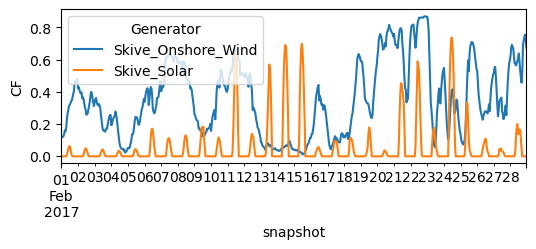

In [828]:
n.generators_t.p_max_pu.loc["2017-02"].plot(figsize=(6, 2), ylabel="CF")

In [829]:
costs.at["battery inverter", "efficiency"]

0.96

In [830]:
"Battery Storage at Skive";

n.add("StorageUnit",
    "Skive_Battery",
    bus="B1",  # Use your electricity bus name
    carrier="battery storage",
    max_hours=4,  # 22 MW * 4 h = 88 MWh
    capital_cost=costs.at["battery inverter", "capital_cost"]
        + 4 * costs.at["battery storage", "capital_cost"],
    efficiency_store = 0.90, # Charging Efficiency
    efficiency_dispatch=costs.at["battery inverter", "efficiency"], # DIscharging Efficiency
    p_nom=22,  # 22 MW
    p_nom_extendable=False,
    cyclic_state_of_charge=True)

Index(['Skive_Battery'], dtype='object')

In [831]:
"Battery WIth Links for Discharge and Charge";


In [832]:
"Adding the Localised Demand in Greenlab Skive";

n.add("Load", "Skive_el_Load", 
      bus="B1", 
      p_set=2) #MWh

Index(['Skive_el_Load'], dtype='object')

In [833]:
"Heat Bus for Boiler";
n.add("Bus", "Heat_Bus_Skive", carrier="heat")

"Boiler at Skive";
n.add("Link","Boiler_Skive",
      bus0 = "B1",
      bus1="Heat_Bus_Skive",
      p_nom = 10, # MW
      efficiency=0.9,
      carrier = "electric boiler",
      capital_cost=costs.at["electric boiler steam","capital_cost"])

n.add("Load", "Skive_Heat_Load", 
      bus="Heat_Bus_Skive",
      p_nom_extendable=False,
      carrier = "heat",
      p_set = 5) # MWh


Index(['Skive_Heat_Load'], dtype='object')

In [834]:
costs.at["Concrete-charger", "capital_cost"]

12686.606707007051

In [835]:
costs.at["Concrete-discharger", "capital_cost"]

46096.51457909899

In [836]:
"Concrete Heat Storage (Rondo)";

n.add("Bus", "TES_Rondo", carrier="heat")

n.add("Store", "Rondo_Concrete_Heat_Storage",
    bus="TES_Rondo",
    e_nom=100, # MWh
    e_nom_extendable=False,
    e_initial=0,
    e_cyclic=True,
    standing_loss= 1.2/100) # 1.2% per hour

"Charging of Rondo ,  El_Bus -> TES_Rondo";
n.add("Link",
      "El_to_TES_Rondo",
      bus0="B1",
      bus1="TES_Rondo",
      p_nom_extendable=False,
      p_nom = 24, # MW
      efficiency=0.98,
      carrier = "electricity",
      capital_cost=costs.at["Concrete-charger", "capital_cost"])

"Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
n.add("Link",
      "TES_Rondo_to_Heat_Bus_Skive",
      bus0="TES_Rondo",
      bus1="Heat_Bus_Skive",
      p_nom = 24,
      p_nom_extendable=False,
      efficiency=0.90,
      capital_cost=costs.at["Concrete-discharger", "capital_cost"])

Index(['TES_Rondo_to_Heat_Bus_Skive'], dtype='object')

In [837]:
DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values

array([20.9     , 18.129999, 16.030001, ...,  4.62    ,  4.71    ,
       -0.27    ])

In [838]:
DK1_data_2017.index.max()


Timestamp('2017-12-30 22:00:00')

In [839]:
DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017)

2017-01-01 00:00:00    20.900000
2017-01-01 01:00:00    18.129999
2017-01-01 02:00:00    16.030001
2017-01-01 03:00:00    16.430000
2017-01-01 04:00:00    13.750000
                         ...    
2017-12-30 18:00:00    27.350000
2017-12-30 19:00:00    17.559999
2017-12-30 20:00:00     4.620000
2017-12-30 21:00:00     4.710000
2017-12-30 22:00:00    -0.270000
Name: DK1_EUR/MWh, Length: 8735, dtype: float64

In [ ]:
"Adding External Grid";
n.add("Bus","Grid_Import", carrier = "electricity")

n.add("Generator","Grid_Generator",
        bus = "Grid_Import",
        p_nom_extendable=True,
        efficiency=1.0,
       marginal_cost=0,
       capital_cost=0.0)

n.add("Link", "Imports",
        bus0 = "Grid_Import",
        bus1 = "B1",
        p_nom_extendable = True,
        efficency = 0.97,
        p_max_pu = 1.0,
        carrier = "electricity",
       marginal_cost= DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values) # + Grid Fee

       #--------------------------------
n.add("Bus","Grid_Export", carrier = "electricity")

n.add("Store", "Grid_Store",
      bus = "Grid_Export",
      e_nom_extendable=True,
      efficiency_store=1.0,
      carrier = "electricity",
      capital_cost=0.0,
      standing_loss=0.0)

n.add("Link","Exports",
        bus0 = "B1",
        bus1 = "Grid_Export",
        p_nom_extendable = True,
        efficiency = 0.97,
        p_max_pu = 1.0,
        carrier = "electricity",
        marginal_cost= -DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values) # + Feed-in-Tariff



Index(['Exports'], dtype='object')

In [841]:
DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values

array([20.9     , 18.129999, 16.030001, ...,  4.62    ,  4.71    ,
       -0.27    ])

In [842]:
DK1_data_2017["DK1_EUR/MWh"].values

array([20.959999, 20.9     , 18.129999, ...,  4.62    ,  4.71    ,
       -0.27    ])

In [843]:
n.optimize(solver_name="gurobi")

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 24.97it/s]
INFO:linopy.io: Writing time: 2.6s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2602524


INFO:gurobipy:Set parameter LicenseID to value 2602524


...

Solved in 24864 iterations and 1.68 seconds (0.52 work units)


INFO:gurobipy:Solved in 24864 iterations and 1.68 seconds (0.52 work units)


Optimal objective -2.884188857e+06


INFO:gurobipy:Optimal objective -2.884188857e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131029 primals, 296994 duals
Objective: -2.88e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

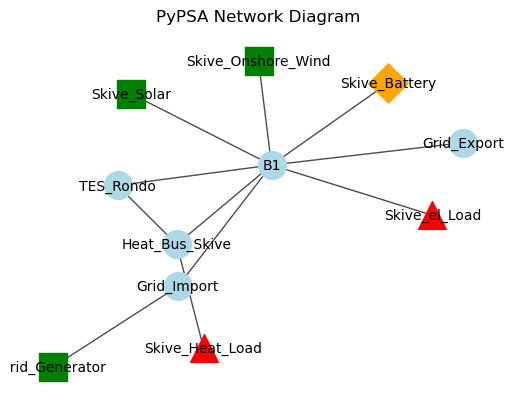

In [883]:
import networkx as nx
import matplotlib.pyplot as plt

# Start with buses and links
G = nx.Graph()

# Add buses
for bus_name in n.buses.index:
    G.add_node(bus_name, type="bus")

# Add links
for link_name, link in n.links.iterrows():
    G.add_edge(link.bus0, link.bus1, type="link", name=link_name)

# Add generators
for gen_name, gen in n.generators.iterrows():
    G.add_node(gen_name, type="generator")
    G.add_edge(gen.bus, gen_name, type="generator_connection")

# Add storage units
for su_name, su in n.storage_units.iterrows():
    G.add_node(su_name, type="storage")
    G.add_edge(su.bus, su_name, type="storage_connection")

# Add loads
for load_name, load in n.loads.iterrows():
    G.add_node(load_name, type="load")
    G.add_edge(load.bus, load_name, type="load_connection")

# Define positions (spring layout or use bus coordinates if available)
pos = nx.spring_layout(G, seed=12)

# Draw edges first
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)

# Draw nodes by type with different shapes
node_shapes = {
    "bus": ("o", "lightblue"),          # circle
    "generator": ("s", "green"),        # square
    "storage": ("D", "orange"),         # diamond
    "load": ("^", "red")                # triangle
}

for ntype, (shape, color) in node_shapes.items():
    nodes_of_type = [node for node, attr in G.nodes(data=True) if attr["type"] == ntype]
    nx.draw_networkx_nodes(G, pos,
                           nodelist=nodes_of_type,
                           node_color=color,
                           node_shape=shape,
                           node_size=400,
                           label=ntype.capitalize())

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10)

# Add legend
#plt.legend(scatterpoints=1)
plt.axis("off")
plt.title("PyPSA Network Diagram")
plt.show()


## Rolling Horizon Command

In [844]:
n.consistency_check()

In [845]:
print(n.buses_t.marginal_price)

Bus                         B1  Heat_Bus_Skive  TES_Rondo  Grid_Import  \
snapshot                                                                 
2017-01-01 00:00:00  20.900000       16.314110  14.682699          0.0   
2017-01-01 01:00:00  18.129999       16.512257  14.861032          0.0   
2017-01-01 02:00:00  16.030001       16.712811  15.041530          0.0   
2017-01-01 03:00:00  16.430000       16.915801  15.224221          0.0   
2017-01-01 04:00:00  13.750000       15.277778  15.409130          0.0   
...                        ...             ...        ...          ...   
2017-12-30 18:00:00  27.350000       30.388889  27.350000          0.0   
2017-12-30 19:00:00  17.559999       19.511110  17.559999          0.0   
2017-12-30 20:00:00   4.620000        5.133333  14.160440          0.0   
2017-12-30 21:00:00   4.710000        5.233333  14.332429          0.0   
2017-12-30 22:00:00  -0.270000       -0.300000  14.506507          0.0   

Bus                  Grid_Export  
sn

In [846]:
"Minimum cost of the system";
n.objective/1e9 # Bn of EUR per annum

-0.0028841888566466817

In [847]:
"Optimal Generator Capacity (GW)";
n.generators.p_nom_opt # in GW

Generator
Skive_Solar           36.000000
Skive_Onshore_Wind    54.000000
Grid_Generator        53.555556
Name: p_nom_opt, dtype: float64

<Axes: xlabel='snapshot'>

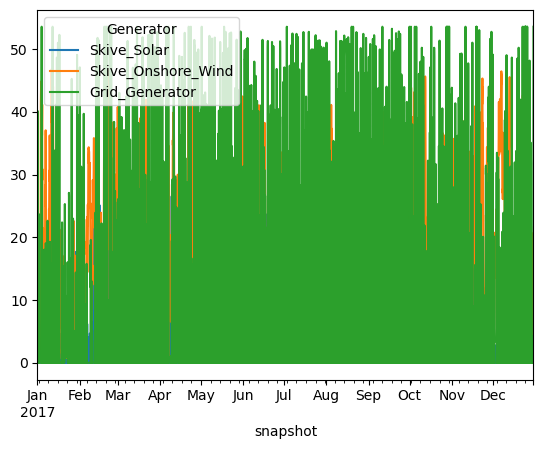

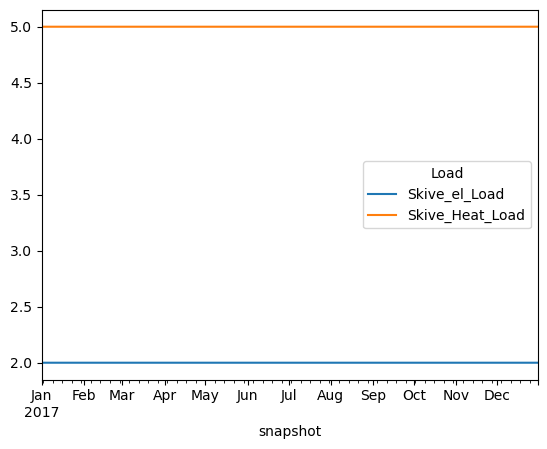

In [848]:
n.generators_t.p.plot()
n.loads_t.p.plot()

In [849]:
"Battery Storage Capacity (MWh)";
n.storage_units.max_hours*n.storage_units.p_nom_opt/4

StorageUnit
Skive_Battery    22.0
dtype: float64

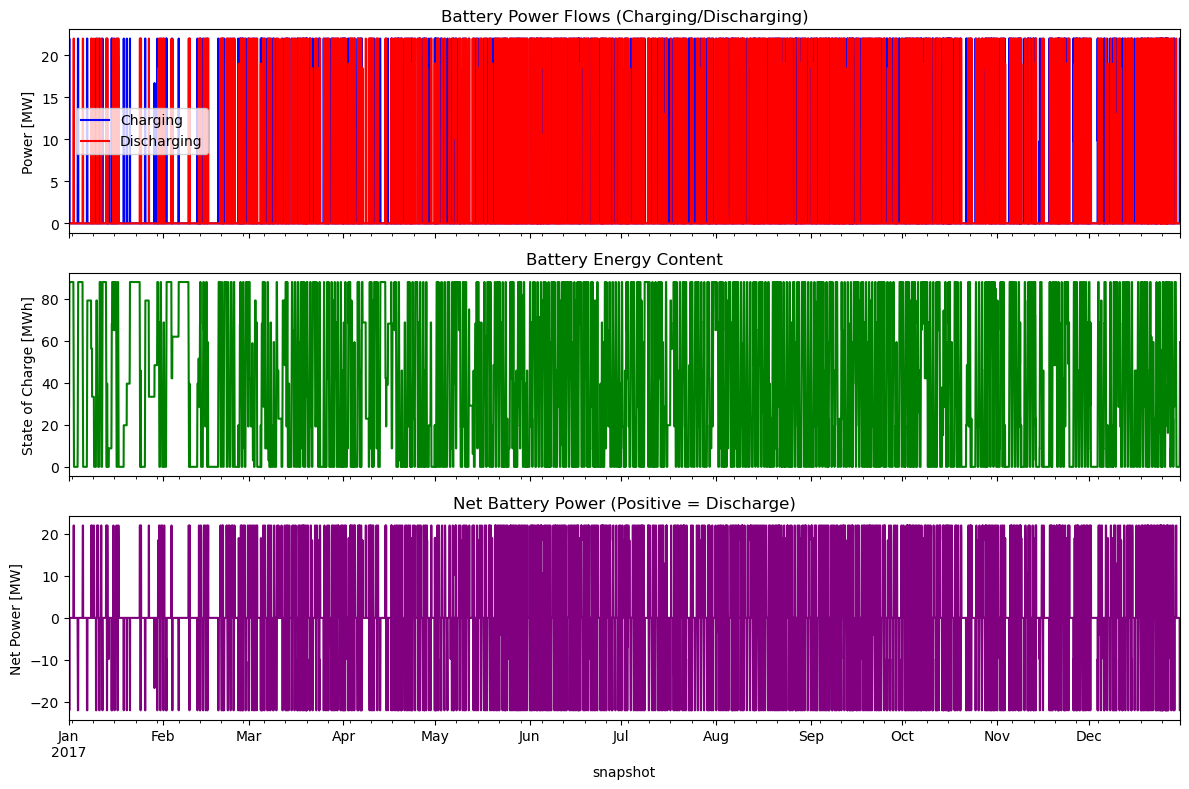

In [850]:
# Discharge power (positive when delivering electricity)
n.storage_units_t.p_dispatch["Skive_Battery"].head()

# Charging power (positive when charging)
n.storage_units_t.p_store["Skive_Battery"].head()

n.storage_units_t.state_of_charge["Skive_Battery"].head()


fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

n.storage_units_t.p_store["Skive_Battery"].plot(ax=ax[0], label="Charging", color="blue")
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax[0], label="Discharging", color="red")
ax[0].set_ylabel("Power [MW]")
ax[0].legend()
ax[0].set_title("Battery Power Flows (Charging/Discharging)")

n.storage_units_t.state_of_charge["Skive_Battery"].plot(ax=ax[1], color="green")
ax[1].set_ylabel("State of Charge [MWh]")
ax[1].set_title("Battery Energy Content")

# Optional: plot net power (discharge - charge)
net_p = n.storage_units_t.p_dispatch["Skive_Battery"] - n.storage_units_t.p_store["Skive_Battery"]
net_p.plot(ax=ax[2], color="purple")
ax[2].set_ylabel("Net Power [MW]")
ax[2].set_title("Net Battery Power (Positive = Discharge)")

plt.tight_layout()
plt.show()


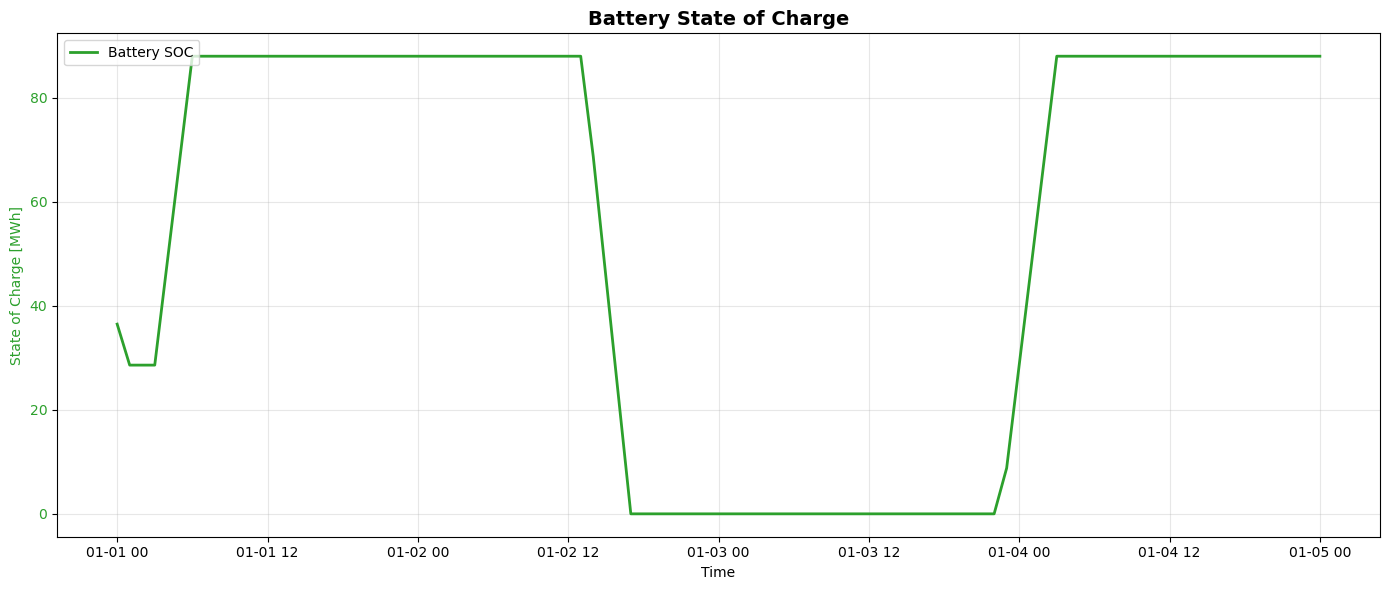

In [852]:
# Plot battery SOC dynamics with charging/discharging power
fig, ax1 = plt.subplots(figsize=(14, 6))

# Primary y-axis: State of Charge (SOC)
color_soc = 'tab:green'
ax1.set_xlabel('Time')
ax1.set_ylabel('State of Charge [MWh]', color=color_soc)

# Use date_range to get proper datetime objects for slicing
start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2017-01-05')

soc_data = n.storage_units_t.state_of_charge["Skive_Battery"].loc[start_date:end_date]
ax1.plot(soc_data, label="Battery SOC", color=color_soc, linewidth=2)

ax1.tick_params(axis='y', labelcolor=color_soc)
ax1.grid(True, alpha=0.3)

# Title and legend
ax1.set_title('Battery State of Charge', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper left')

plt.tight_layout()
plt.show()

<Axes: xlabel='snapshot'>

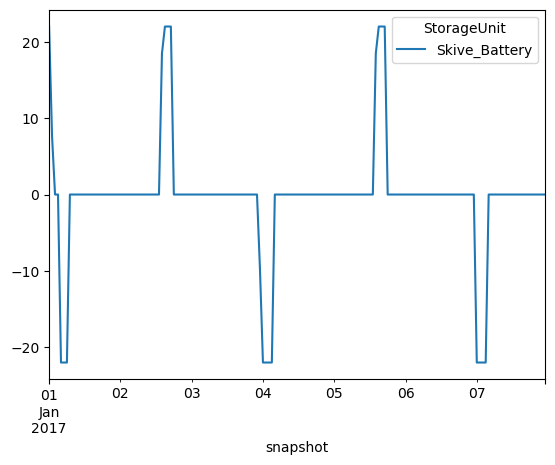

In [853]:
n.storage_units_t.p.loc["2017-01-01":"2017-01-07"].plot()

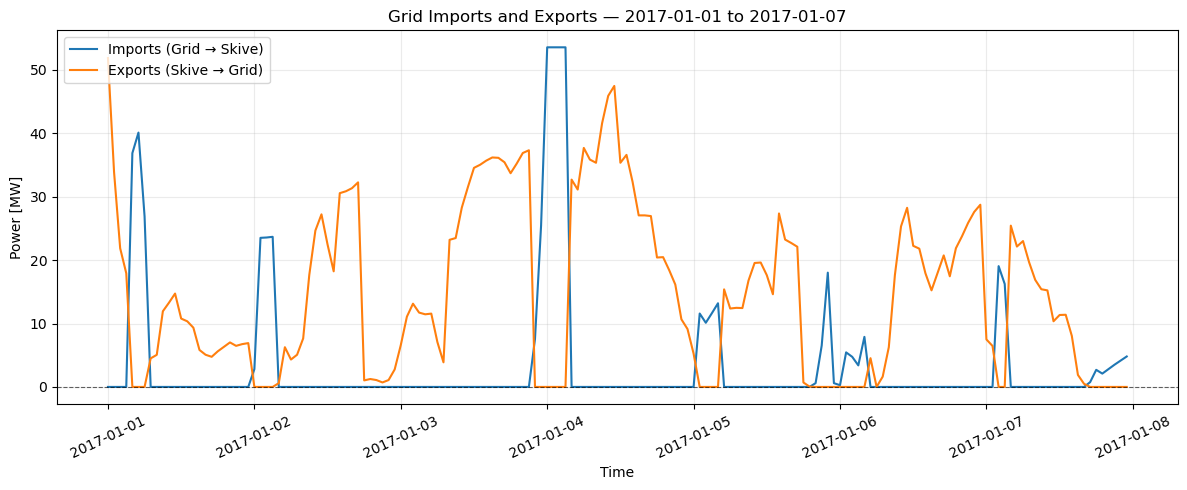

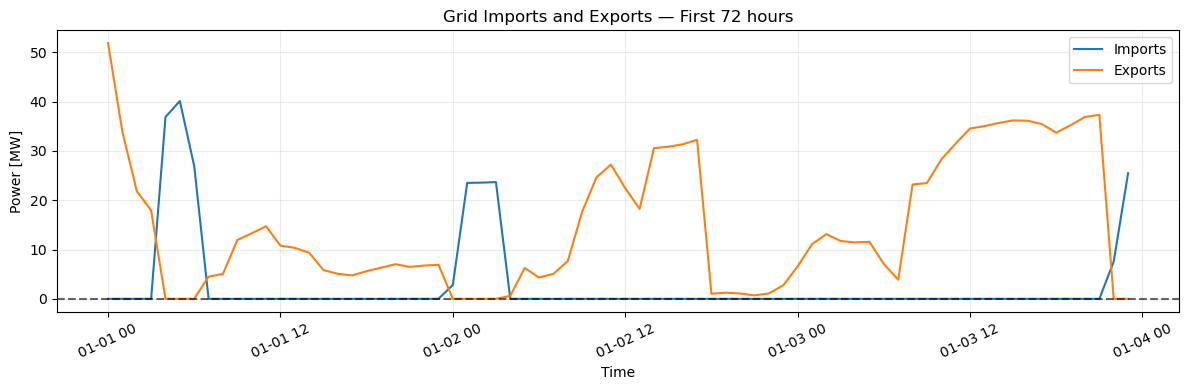

In [854]:
# ...existing code...
import matplotlib.dates as mdates

# align to network snapshots (fill missing with 0)
imports = n.links_t.p0["Imports"].reindex(n.snapshots).fillna(0)
exports = n.links_t.p0["Exports"].reindex(n.snapshots).fillna(0)

# choose timeframe
start_date = "2017-01-01"
end_date   = "2017-01-07"

# full week plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(imports.loc[start_date:end_date].index, imports.loc[start_date:end_date].values,
        label="Imports (Grid → Skive)", color="#1f77b4", linewidth=1.5)
ax.plot(exports.loc[start_date:end_date].index, exports.loc[start_date:end_date].values,
        label="Exports (Skive → Grid)", color="#ff7f0e", linewidth=1.5)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Grid Imports and Exports — {start_date} to {end_date}")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# zoom: first 72 hours
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(imports.iloc[0:24*3].index, imports.iloc[0:24*3].values, label="Imports", color="#1f77b4")
ax.plot(exports.iloc[0:24*3].index, exports.iloc[0:24*3].values, label="Exports", color="#ff7f0e")
ax.axhline(0, color="k", linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title("Grid Imports and Exports — First 72 hours")
ax.legend()
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [855]:
n.links_t.p0

Link,Boiler_Skive,El_to_TES_Rondo,TES_Rondo_to_Heat_Bus_Skive,Imports,Exports
snapshot,,,,,
2017-01-01 00:00:00,0.000000,0.0,5.555556,0.000000,51.860
2017-01-01 01:00:00,0.000000,0.0,5.555556,0.000000,33.864
2017-01-01 02:00:00,0.000000,0.0,5.555556,0.000000,21.868
2017-01-01 03:00:00,0.000000,0.0,5.555556,0.000000,17.926
2017-01-01 04:00:00,5.555556,24.0,0.000000,36.869556,0.000
...,...,...,...,...,...
2017-12-30 18:00:00,5.555556,0.0,0.000000,3.505556,0.000
2017-12-30 19:00:00,5.555556,0.0,0.000000,4.261556,0.000
2017-12-30 20:00:00,5.555556,24.0,0.000000,49.667556,0.000


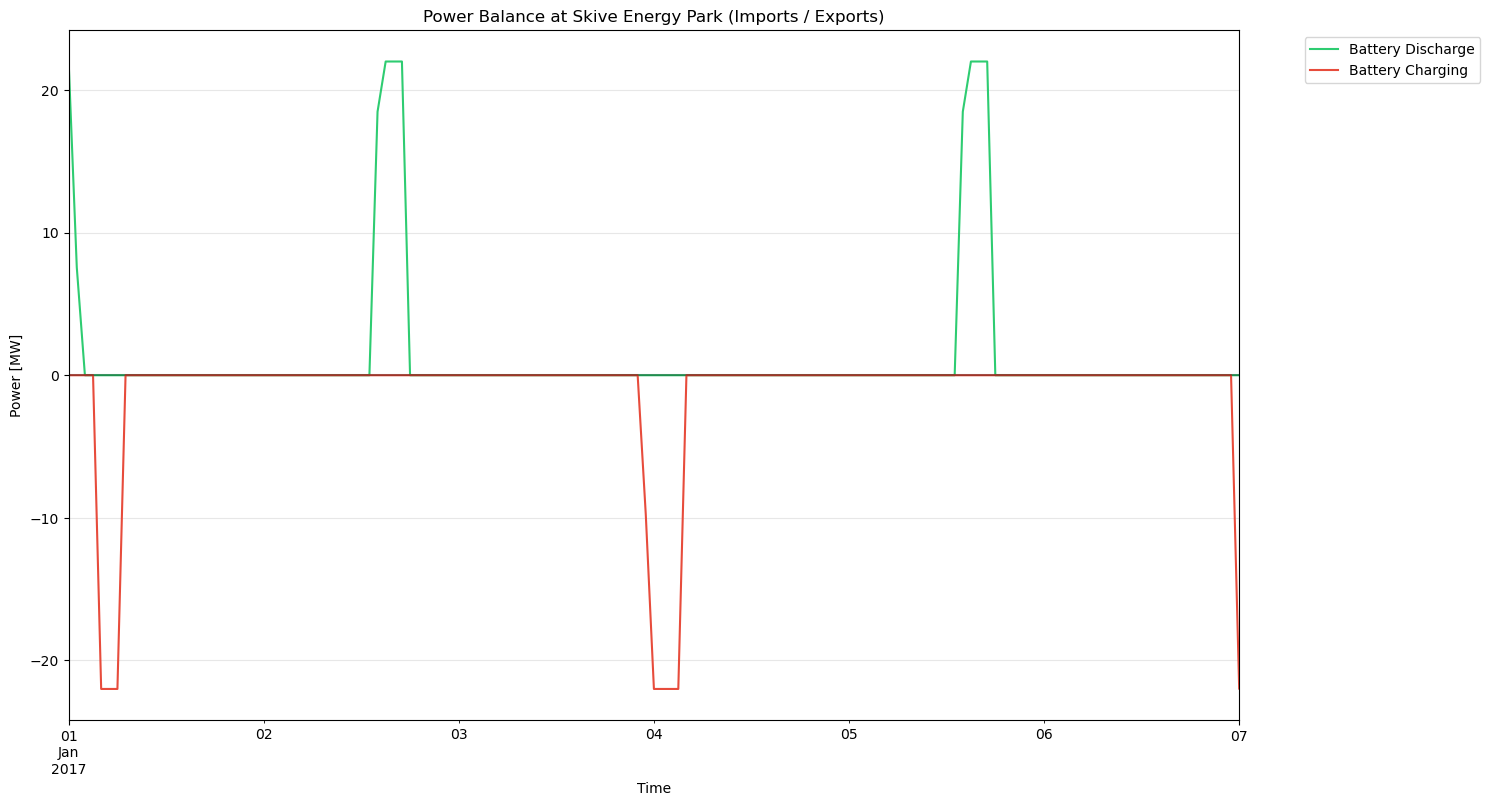

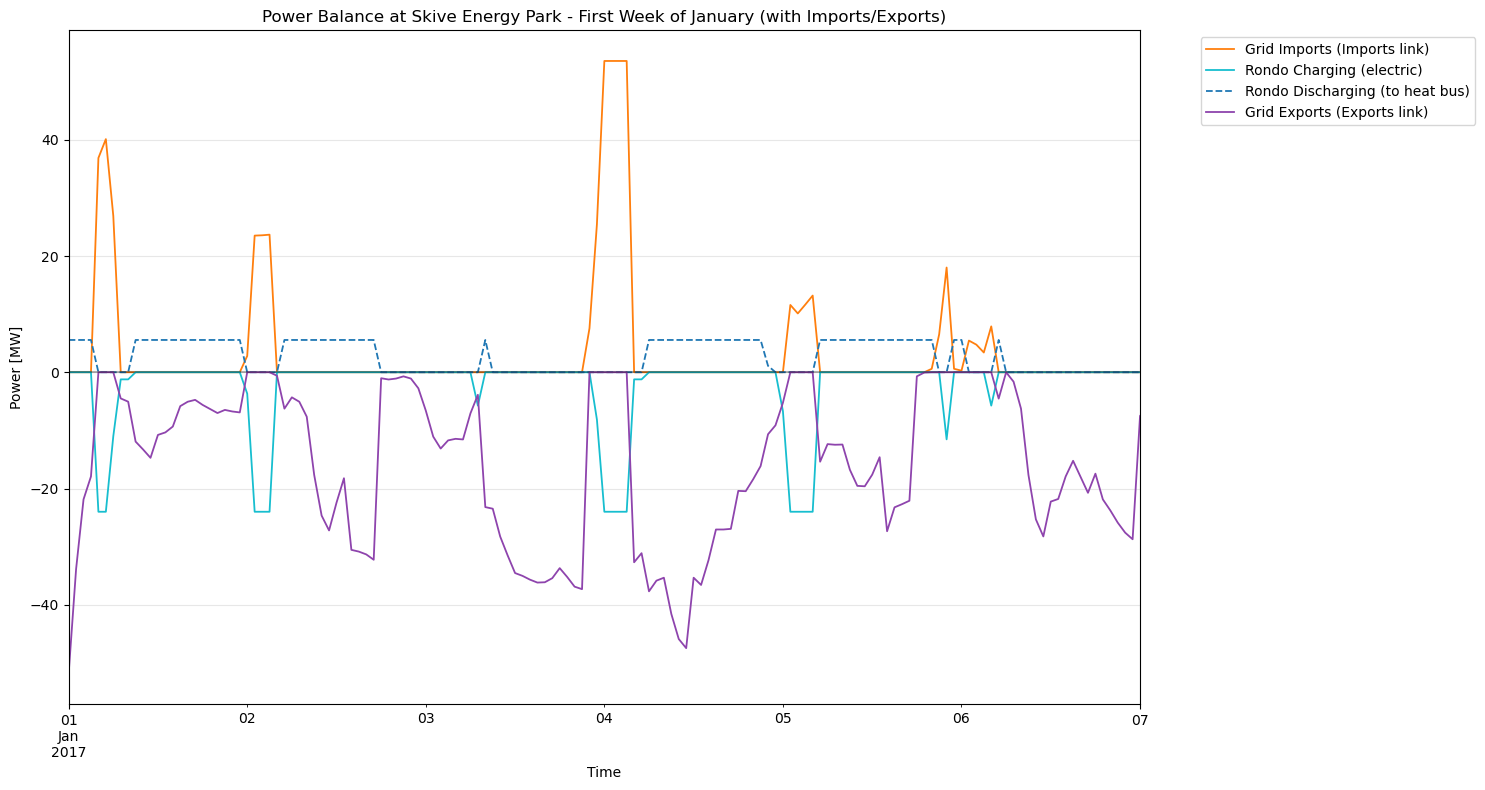

In [856]:
# ...existing code...
import matplotlib.dates as mdates

def safe_series(df, key):
    try:
        return df[key].reindex(n.snapshots).fillna(0)
    except Exception:
        return pd.Series(0.0, index=n.snapshots, name=key)

# read Imports/Exports (fall back to zero series if missing)
imports = safe_series(n.links_t.p0, "Imports")
exports = safe_series(n.links_t.p0, "Exports")

exports = -exports  # invert sign for exports to match convention

# positive import = grid -> B1, positive export = B1 -> grid
#imports_pos = imports.clip(lower=0)
#exports_pos = exports.clip(lower=0

start_date = '2017-01-01'
end_date = '2017-01-07'

# colors
col_grid_imp = '#FF7F0E'
col_grid_exp = '#8E44AD'

# Main plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# battery and rondo flows (existing)
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax, label="Battery Discharge", color='#2ECC71', linewidth=1.5)
(-n.storage_units_t.p_store["Skive_Battery"]).plot(ax=ax, label="Battery Charging", color='#E74C3C', linewidth=1.5)

#(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots))).plot(ax=ax, label="Rondo Charging (electric)", color='#17BECF', linewidth=1.25)
#n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).plot(ax=ax, label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.25)

# plot Imports/Exports
#imports.plot(ax=ax, label="Imports (Imports link)", color=col_grid_imp, linewidth=1.3, alpha=0.9)
#exports.plot(ax=ax, label="Exports (Exports link)", color=col_grid_exp, linewidth=1.3, alpha=0.9)

ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Power [MW]')
ax.set_title('Power Balance at Skive Energy Park (Imports / Exports)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xlim(start_date, end_date)
plt.show()

# Week view
plt.figure(figsize=(15, 8))

#n.generators_t.p["Skive_Solar"].loc[start_date:end_date].plot(label="Solar PV", color='#FFC300', linewidth=1.3)
#n.generators_t.p["Skive_Onshore_Wind"].loc[start_date:end_date].plot(label="Wind", color='#0057E7', linewidth=1.3)
#n.storage_units_t.p_dispatch["Skive_Battery"].loc[start_date:end_date].plot(label="Battery Discharge", color='#2ECC71', linewidth=1.3)
imports.loc[start_date:end_date].plot(label="Grid Imports (Imports link)", color=col_grid_imp, linewidth=1.3)
#(-n.links_t.p0.get("Boiler_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Electric Boiler", color='#7F8C8D', linewidth=1.3)
(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Rondo Charging (electric)", color='#17BECF', linewidth=1.3)
n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date].plot(label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.3)
#(-n.storage_units_t.p_store["Skive_Battery"].loc[start_date:end_date]).plot(label="Battery Charging", color='#E74C3C', linewidth=1.3)
exports.loc[start_date:end_date].plot(label="Grid Exports (Exports link)", color=col_grid_exp, linewidth=1.3)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Power [MW]')
plt.title('Power Balance at Skive Energy Park - First Week of January (with Imports/Exports)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(start_date, end_date)
plt.tight_layout()
plt.show()

In [800]:
# Or the full timeseries
grid_exchange = n.links_t.p0["Grid_Exchange"]
print(grid_exchange)

# Optional: simple plot
import matplotlib.pyplot as plt

grid_exchange.plot(figsize=(12,5))
plt.title("Power Exchange: Grid ↔ Skive (MW)")
plt.xlabel("Time")
plt.ylabel("Power [MW]")
plt.axhline(0, color='black', linestyle='--')  # zero line: positive = import, negative = export
#plt.xlim('2017-01-01 00:00Z', '2017-01-02 00:00Z')
plt.show()

KeyError: 'Grid_Exchange'

<Axes: xlabel='snapshot'>

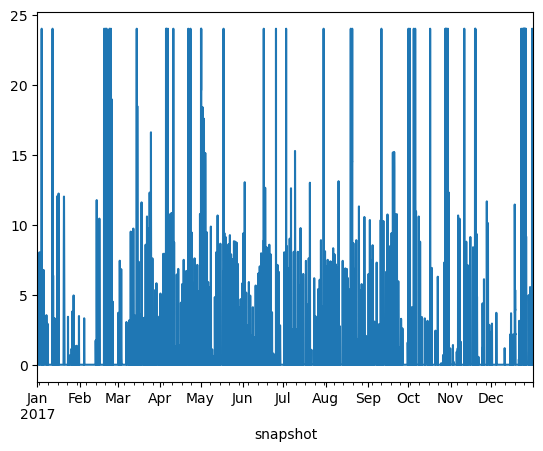

(412008.0, 412056.0)

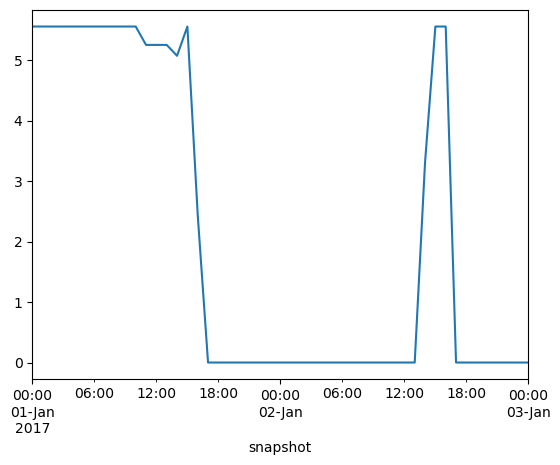

In [643]:
display(n.links_t.p0["El_to_TES_Rondo"].plot())
plt.show()
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].plot()
plt.xlim('2017-01-01 00:00Z', '2017-01-03 00:00Z')


<Axes: xlabel='snapshot'>

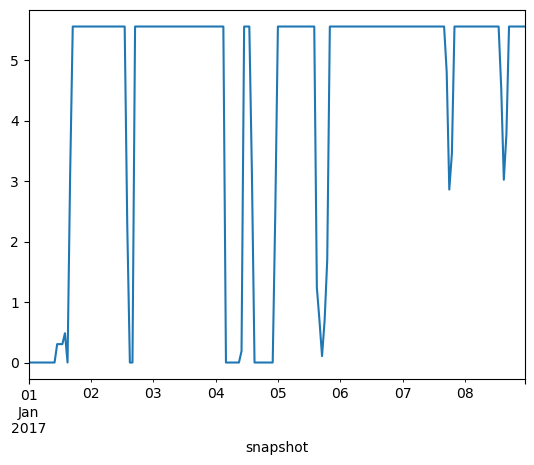

In [644]:
n.links_t.p0["Boiler_Skive"]["2017-01-01":"2017-01-08"].plot()

In [645]:
print(n.links.p_nom_opt["Grid_Exchange"])


KeyError: 'Grid_Exchange'

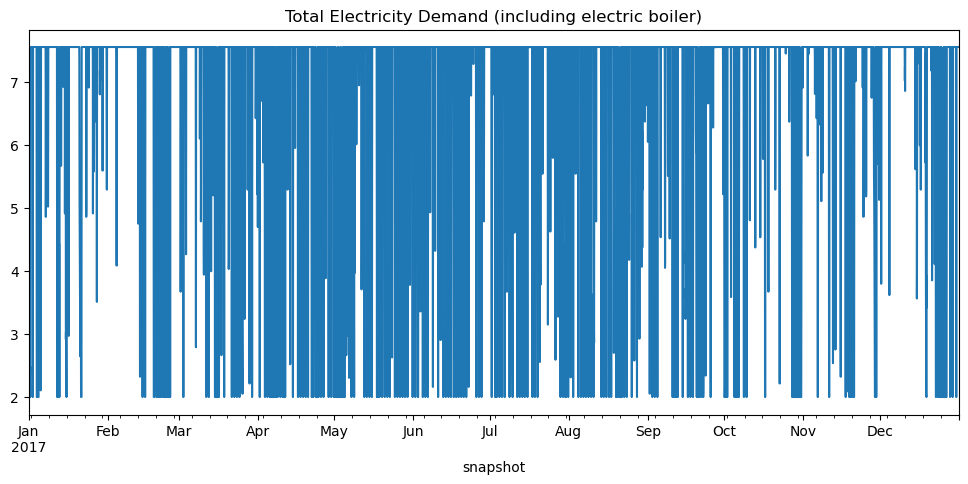

In [646]:
# Total electricity demand (load + electric boiler)
total_electric_load = n.loads_t.p["Skive_el_Load"] + n.links_t.p0["Boiler_Skive"]
total_electric_load.plot(figsize=(12,5))
plt.title("Total Electricity Demand (including electric boiler)")
plt.show()


In [647]:
n.storage_units_t.state_of_charge

StorageUnit,Skive_Battery
snapshot,
2017-01-01 00:00:00,85.916667
2017-01-01 01:00:00,83.833333
2017-01-01 02:00:00,81.750000
2017-01-01 03:00:00,79.666667
2017-01-01 04:00:00,77.583333
...,...
2017-12-31 19:00:00,17.526667
2017-12-31 20:00:00,24.640000
2017-12-31 21:00:00,45.760000


<Axes: xlabel='snapshot'>

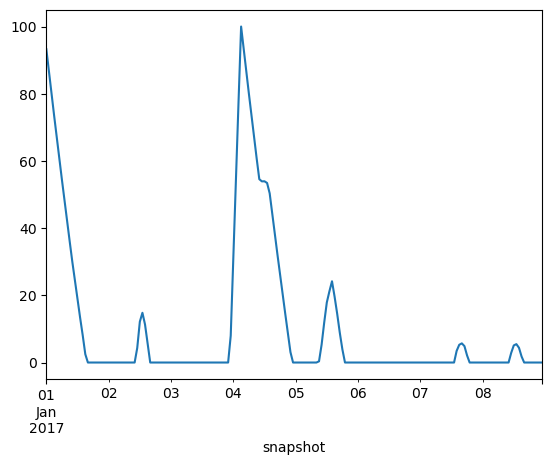

In [648]:
n.stores_t.e["Rondo_Concrete_Heat_Storage"]["2017-01-01":"2017-01-08"].plot()


KeyError: 'Grid_Exchange'

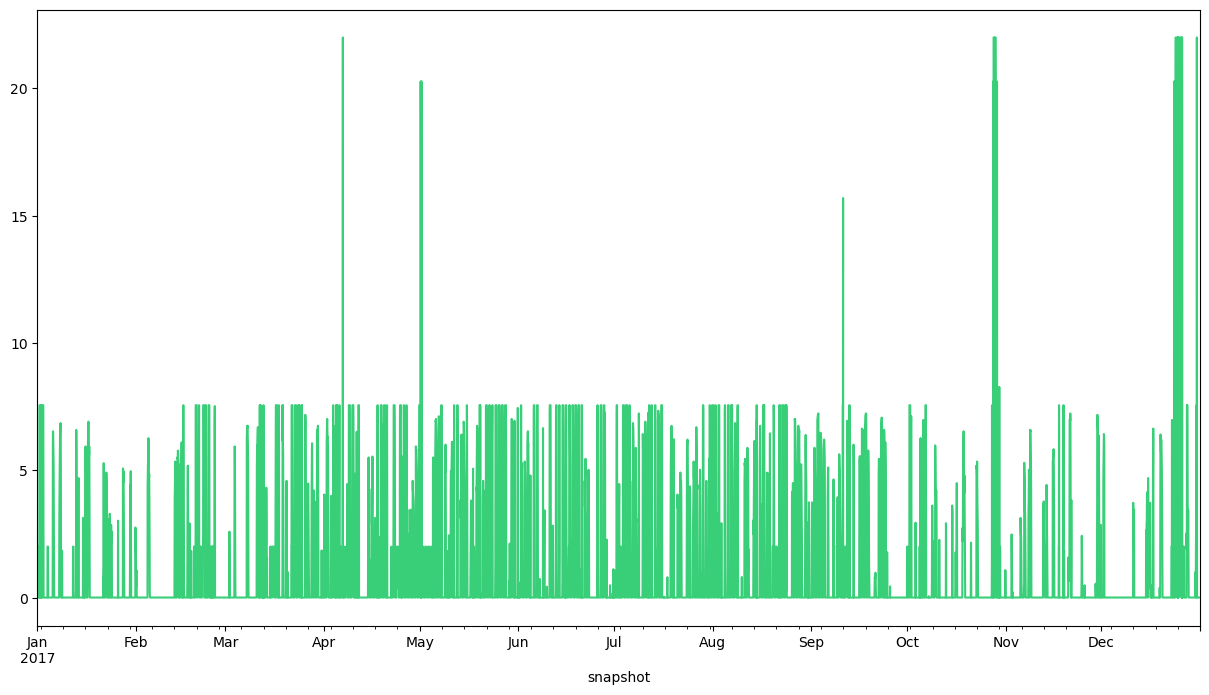

In [649]:
# ...existing code...
# Create power balance plot with Rondo flows
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Use a more distinct color palette
col_solar = '#FFC300'        # vivid yellow
col_wind = '#0057E7'         # strong blue
col_batt_dis = '#2ECC71'     # bright green
col_batt_ch = '#E74C3C'      # vivid red
col_grid_imp = '#FF7F0E'     # orange
col_grid_exp = '#8E44AD'     # purple
col_boiler = '#7F8C8D'       # gray
col_rondo = '#17BECF'        # cyan

# Generation (positive)
n.storage_units_t.p_dispatch["Skive_Battery"].plot(
    ax=ax, label="Battery Discharge", color=col_batt_dis, alpha=0.95, linewidth=1.5
)
grid_imports = n.links_t.p0["Grid_Exchange"].clip(lower=0)

# Consumption (negative)
(-n.storage_units_t.p_store["Skive_Battery"]).plot(
    ax=ax, label="Battery Charging", color=col_batt_ch, alpha=0.95, linewidth=1.5
)
grid_exports = -n.links_t.p0["Grid_Exchange"].clip(upper=0)

# Formatting
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Power [MW]')
ax.set_title('Power Balance at Skive Energy Park (including Rondo heat storage)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Week view with same distinct colors
plt.figure(figsize=(15, 8))
start_date = '2017-01-01'
end_date = '2017-01-07'  # Showing a full week

n.generators_t.p["Skive_Solar"].loc[start_date:end_date].plot(
    label="Solar PV", color=col_solar, alpha=0.95, linewidth=1.3
)
n.generators_t.p["Skive_Onshore_Wind"].loc[start_date:end_date].plot(
    label="Wind", color=col_wind, alpha=0.95, linewidth=1.3
)
#n.storage_units_t.p_dispatch["Skive_Battery"].loc[start_date:end_date].plot(
 #   label="Battery Discharge", color=col_batt_dis, alpha=0.95, linewidth=1.3
#)
#grid_imports.loc[start_date:end_date].plot(
 #   label="Grid Import", color=col_grid_imp, alpha=0.95, linewidth=1.3
#)
(-n.links_t.p0["Boiler_Skive"].loc[start_date:end_date]).plot(
    label="Electric Boiler", color=col_boiler, alpha=0.95, linewidth=1.3
)
(-n.links_t.p0["El_to_TES_Rondo"].loc[start_date:end_date]).plot(
    label="Rondo Charging", color=col_rondo, alpha=0.95, linewidth=1.3
)
(-n.storage_units_t.p_store["Skive_Battery"].loc[start_date:end_date]).plot(
    label="Battery Charging", color=col_batt_ch, alpha=0.95, linewidth=1.3
)
(-grid_exports.loc[start_date:end_date]).plot(
    label="Grid Export", color=col_grid_exp, alpha=0.95, linewidth=1.3
)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Power [MW]')
plt.title('Power Balance at Skive Energy Park - First Week of January')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# ...existing code...

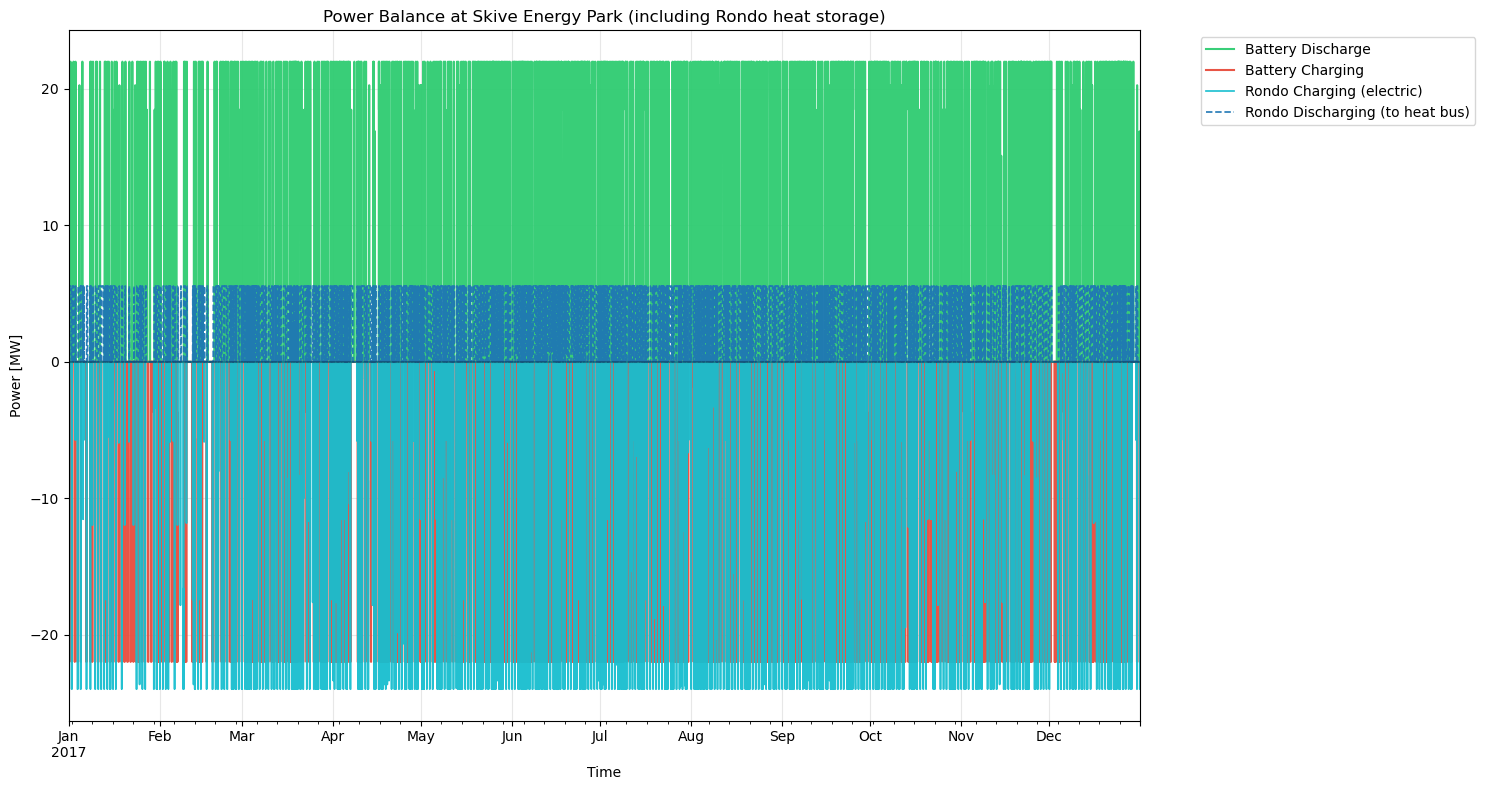

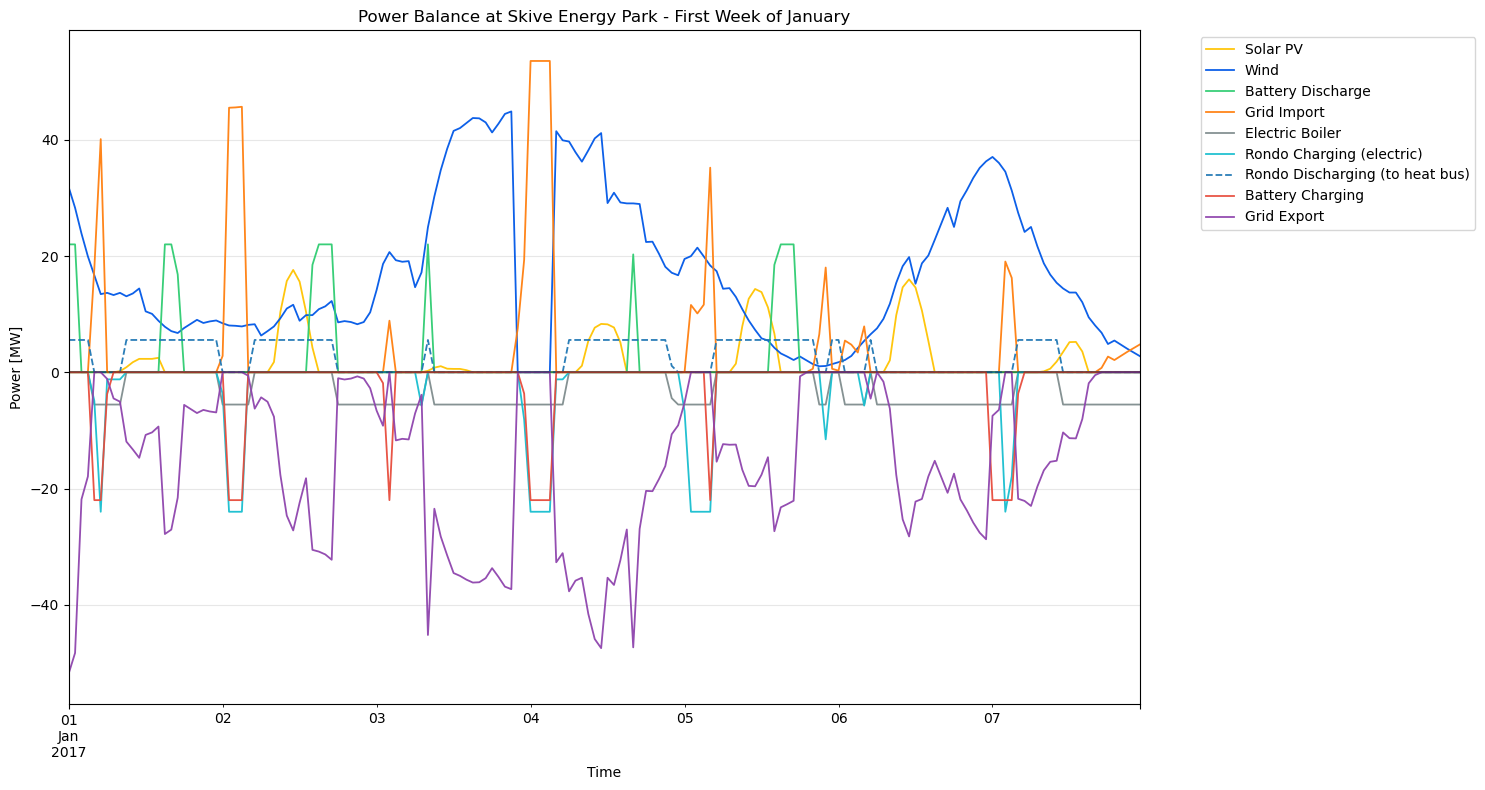

In [525]:
# ...existing code...
# Create power balance plot with Rondo flows
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Use a more distinct color palette
col_solar = '#FFC300'        # vivid yellow
col_wind = '#0057E7'         # strong blue
col_batt_dis = '#2ECC71'     # bright green
col_batt_ch = '#E74C3C'      # vivid red
col_grid_imp = '#FF7F0E'     # orange
col_grid_exp = '#8E44AD'     # purple
col_boiler = '#7F8C8D'       # gray
col_rondo_ch = '#17BECF'     # cyan (Rondo charging)
col_rondo_dis = '#1F77B4'    # blue (Rondo discharging)

# Generation (positive)
n.storage_units_t.p_dispatch["Skive_Battery"].plot(
    ax=ax, label="Battery Discharge", color=col_batt_dis, alpha=0.95, linewidth=1.5
)
grid_imports = n.links_t.p0["Grid_Exchange"].clip(lower=0)

# Consumption (negative)
(-n.storage_units_t.p_store["Skive_Battery"]).plot(
    ax=ax, label="Battery Charging", color=col_batt_ch, alpha=0.95, linewidth=1.5
)

# Rondo: charging is electricity -> TES (electricity consumption, plot as negative)
(-n.links_t.p0["El_to_TES_Rondo"]).plot(
    ax=ax, label="Rondo Charging (electric)", color=col_rondo_ch, alpha=0.95, linewidth=1.25
)

# Rondo discharging: TES -> Heat (heat delivered). plot as positive heat flow (different color)
# Note: this is a heat flow (same units MW) coming from Rondo storage to the heat bus.
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].plot(
    ax=ax, label="Rondo Discharging (to heat bus)", color=col_rondo_dis, alpha=0.95, linewidth=1.25, linestyle='--'
)

grid_exports = -n.links_t.p0["Grid_Exchange"].clip(upper=0)

# Formatting
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Power [MW]')
ax.set_title('Power Balance at Skive Energy Park (including Rondo heat storage)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Week view with same distinct colors
plt.figure(figsize=(15, 8))
start_date = '2017-01-01'
end_date = '2017-01-07'  # Showing a full week

n.generators_t.p["Skive_Solar"].loc[start_date:end_date].plot(
    label="Solar PV", color=col_solar, alpha=0.95, linewidth=1.3
)
n.generators_t.p["Skive_Onshore_Wind"].loc[start_date:end_date].plot(
    label="Wind", color=col_wind, alpha=0.95, linewidth=1.3
)
n.storage_units_t.p_dispatch["Skive_Battery"].loc[start_date:end_date].plot(
    label="Battery Discharge", color=col_batt_dis, alpha=0.95, linewidth=1.3
)
grid_imports.loc[start_date:end_date].plot(
    label="Grid Import", color=col_grid_imp, alpha=0.95, linewidth=1.3
)

(-n.links_t.p0["Boiler_Skive"].loc[start_date:end_date]).plot(
    label="Electric Boiler", color=col_boiler, alpha=0.95, linewidth=1.3
)
(-n.links_t.p0["El_to_TES_Rondo"].loc[start_date:end_date]).plot(
    label="Rondo Charging (electric)", color=col_rondo_ch, alpha=0.95, linewidth=1.3
)
# Rondo discharging (heat) for the week
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].loc[start_date:end_date].plot(
    label="Rondo Discharging (to heat bus)", color=col_rondo_dis, alpha=0.95, linewidth=1.3, linestyle='--'
)
(-n.storage_units_t.p_store["Skive_Battery"].loc[start_date:end_date]).plot(
    label="Battery Charging", color=col_batt_ch, alpha=0.95, linewidth=1.3
)
(-grid_exports.loc[start_date:end_date]).plot(
    label="Grid Export", color=col_grid_exp, alpha=0.95, linewidth=1.3
)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Power [MW]')
plt.title('Power Balance at Skive Energy Park - First Week of January')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Axes: xlabel='HourUTC'>

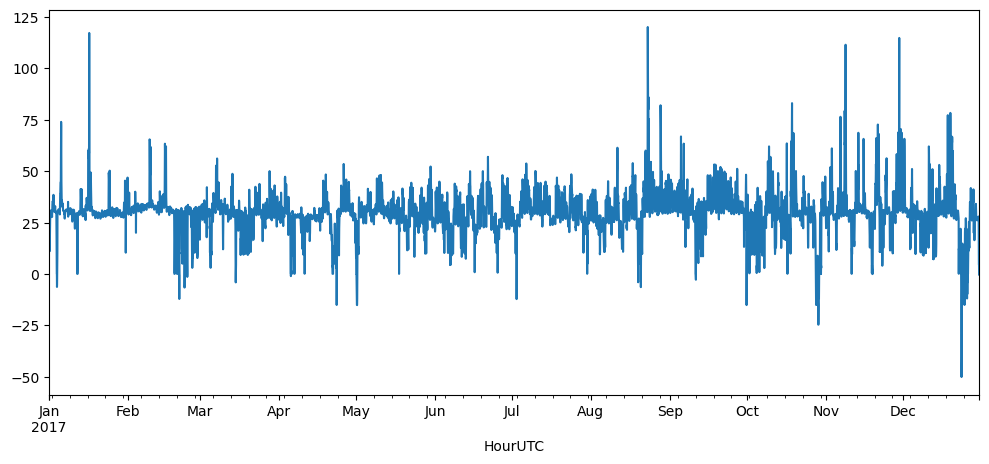

In [526]:
DK1_data_2017["DK1_EUR/MWh"].plot(figsize=(12,5))

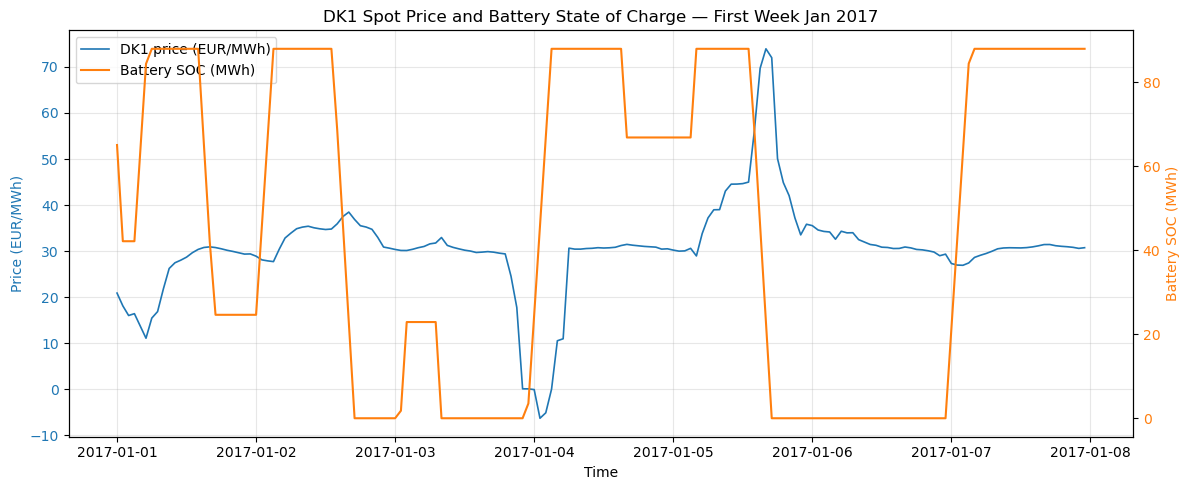

In [527]:
# Plot DK1 price and battery SOC together
start_date = "2017-01-01"
end_date   = "2017-01-07"

# align series to network snapshots, fill missing price values forward
price = DK1_data_2017["DK1_EUR/MWh"].reindex(n.snapshots).ffill()
soc   = n.storage_units_t.state_of_charge["Skive_Battery"].reindex(n.snapshots)

# restrict to timeframe
price_w = price.loc[start_date:end_date]
soc_w   = soc.loc[start_date:end_date]

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(price_w.index, price_w.values, color="#1f77b4", label="DK1 price (EUR/MWh)", linewidth=1.2)
ax1.set_xlabel("Time")
ax1.set_ylabel("Price (EUR/MWh)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(soc_w.index, soc_w.values, color="#ff7f0e", label="Battery SOC (MWh)", linewidth=1.5)
ax2.set_ylabel("Battery SOC (MWh)", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")

# combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("DK1 Spot Price and Battery State of Charge — First Week Jan 2017")
plt.tight_layout()
plt.show()

<Axes: xlabel='snapshot'>

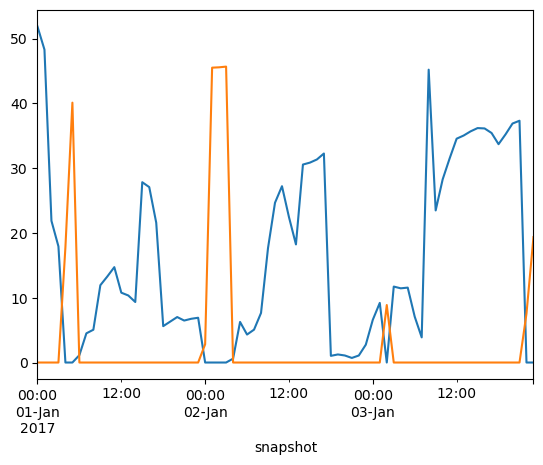

In [528]:
grid_exports[0:24*3].plot()
grid_imports[0:24*3].plot()

In [529]:
df.index

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 01:00:00',
               '2017-01-01 02:00:00', '2017-01-01 03:00:00',
               '2017-01-01 04:00:00', '2017-01-01 05:00:00',
               '2017-01-01 06:00:00', '2017-01-01 07:00:00',
               '2017-01-01 08:00:00', '2017-01-01 09:00:00',
               ...
               '2017-12-31 14:00:00', '2017-12-31 15:00:00',
               '2017-12-31 16:00:00', '2017-12-31 17:00:00',
               '2017-12-31 18:00:00', '2017-12-31 19:00:00',
               '2017-12-31 20:00:00', '2017-12-31 21:00:00',
               '2017-12-31 22:00:00', '2017-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [530]:
time

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 01:00:00',
               '2017-01-01 02:00:00', '2017-01-01 03:00:00',
               '2017-01-01 04:00:00', '2017-01-01 05:00:00',
               '2017-01-01 06:00:00', '2017-01-01 07:00:00',
               '2017-01-01 08:00:00', '2017-01-01 09:00:00',
               ...
               '2017-12-31 14:00:00', '2017-12-31 15:00:00',
               '2017-12-31 16:00:00', '2017-12-31 17:00:00',
               '2017-12-31 18:00:00', '2017-12-31 19:00:00',
               '2017-12-31 20:00:00', '2017-12-31 21:00:00',
               '2017-12-31 22:00:00', '2017-12-31 23:00:00'],
              dtype='datetime64[ns]', length=8760, freq=None)

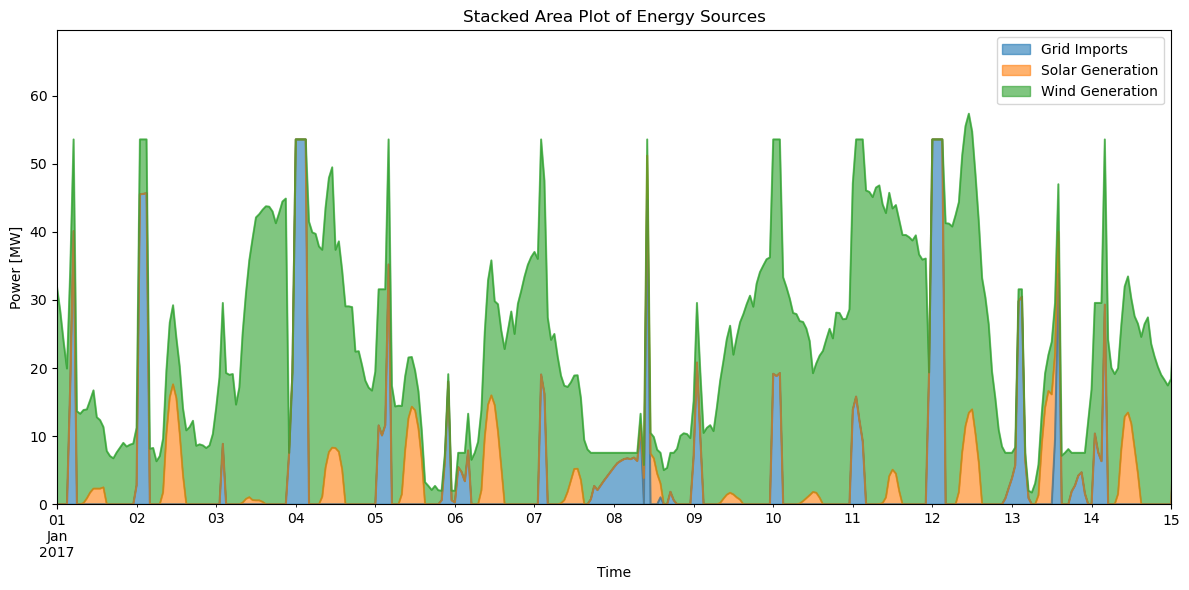

In [539]:
# ...existing code...

start_date = '2017-01-01'
end_date = '2017-01-15'  # Showing a full week

# Create a stacked area plot for wind generation, solar generation, and grid imports
df = pd.DataFrame({
    'Grid Imports': n.links_t.p0["Grid_Exchange"].clip(lower=0),
    'Solar Generation': n.generators_t.p["Skive_Solar"],
    'Wind Generation': n.generators_t.p["Skive_Onshore_Wind"],
})

ax = df.plot.area(figsize=(12, 6), alpha=0.6)

# Formatting
ax.set_title('Stacked Area Plot of Energy Sources')
ax.set_xlabel('Time')
ax.set_xlim(start_date,end_date)
ax.set_ylabel('Power [MW]')
plt.tight_layout()
plt.show()

# ...existing code...

In [532]:
solar_generation

timestamp
2017-01-01 00:00:00    0.0
2017-01-01 01:00:00    0.0
2017-01-01 02:00:00    0.0
2017-01-01 03:00:00    0.0
2017-01-01 04:00:00    0.0
                      ... 
2017-12-31 19:00:00    0.0
2017-12-31 20:00:00    0.0
2017-12-31 21:00:00    0.0
2017-12-31 22:00:00    0.0
2017-12-31 23:00:00    0.0
Name: Skive_Solar, Length: 8760, dtype: float64

In [533]:
# ...existing code...

# --- Save results to CSV for every time step ---
import os

out_dir = r"C:\Users\Pulin\Desktop\Msc_Thesis_Greenlab_Skive"
os.makedirs(out_dir, exist_ok=True)

def safe_series(df, key):
    try:
        return df[key]
    except Exception:
        # return zero series if not present
        return pd.Series(0.0, index=n.snapshots, name=key)

series_dict = {
    "Skive_Solar": safe_series(n.generators_t.p, "Skive_Solar"),
    "Skive_Onshore_Wind": safe_series(n.generators_t.p, "Skive_Onshore_Wind"),
    "Battery_Dispatch_MW": safe_series(n.storage_units_t.p_dispatch, "Skive_Battery"),
    "Battery_Charge_MW": safe_series(n.storage_units_t.p_store, "Skive_Battery"),
    "Battery_SOC_MWh": safe_series(n.storage_units_t.state_of_charge, "Skive_Battery"), 
    "Skive_el_Load_MW": safe_series(n.loads_t.p, "Skive_el_Load"),
    "Boiler_Skive_MW": safe_series(n.links_t.p0, "Boiler_Skive"),
    "El_to_TES_Rondo_MW": safe_series(n.links_t.p0, "El_to_TES_Rondo"),
    "TES_Rondo_to_Heat_MW": safe_series(n.links_t.p0, "TES_Rondo_to_Heat_Bus_Skive"),
    "Grid_Exchange_MW": safe_series(n.links_t.p0, "Grid_Exchange"),
    "Rondo_Energy_MWh": safe_series(n.stores_t.e, "Rondo_Concrete_Heat_Storage")
}

results_ts = pd.DataFrame(series_dict)
results_ts.index.name = "timestamp"

# quick check: show first rows (equivalent to .head() you mentioned)
print(results_ts[["Battery_SOC_MWh"]].head())

# Save full-year results
full_csv = os.path.join(out_dir, "Skive_results_timeseries_fullyear.csv")
results_ts.to_csv(full_csv)

# Save week subset (first week of January)
start_date = "2017-01-01"
end_date = "2017-01-07"
week_ts = results_ts.loc[start_date:end_date]
week_csv = os.path.join(out_dir, "Skive_results_timeseries_week1_jan2017.csv")
week_ts.to_csv(week_csv)

print(f"Saved full timeseries -> {full_csv}")
print(f"Saved week timeseries -> {week_csv}")

# ...existing code...

                     Battery_SOC_MWh
timestamp                           
2017-01-01 00:00:00        65.083333
2017-01-01 01:00:00        42.166667
2017-01-01 02:00:00        42.166667
2017-01-01 03:00:00        42.166667
2017-01-01 04:00:00        63.286667
Saved full timeseries -> C:\Users\Pulin\Desktop\Msc_Thesis_Greenlab_Skive\Skive_results_timeseries_fullyear.csv
Saved week timeseries -> C:\Users\Pulin\Desktop\Msc_Thesis_Greenlab_Skive\Skive_results_timeseries_week1_jan2017.csv
